In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import joblib

In [2]:
train_test_sets = joblib.load('../../data/processed/train_test_sets.pkl')
X_train, X_test, y_train, y_test = train_test_sets['A1_CART']
 
print(f"\n  Train: {X_train.shape} | Test: {X_test.shape}")


  Train: (10811, 3) | Test: (4634, 3)


## CART - ANALIZA A1

-   Variabile: PageValues, BounceRates, VisitorType

### Arbore FARA PRUNING (de referinta)

In [3]:
cart_full = DecisionTreeClassifier(
    criterion='gini',
    splitter='best',
    random_state=7
)
cart_full.fit(X_train, y_train)
 
print(f"\n── 8.1 ARBORE FĂRĂ PRUNING ──")
print(f"Adâncime maximă : {cart_full.get_depth()}")
print(f"Număr noduri : {cart_full.tree_.node_count}")
print(f"Număr frunze: {cart_full.get_n_leaves()}")
print(f"Accuracy train : {cart_full.score(X_train, y_train):.4f}")
print(f"Accuracy test: {cart_full.score(X_test, y_test):.4f}")
overfitting = cart_full.score(X_train, y_train) - cart_full.score(X_test, y_test)
print(f"Diferență (overfit): {overfitting:.4f} {'overfit boss' if overfitting > 0.05 else 'ok boss'}")


── 8.1 ARBORE FĂRĂ PRUNING ──
Adâncime maximă : 45
Număr noduri : 2835
Număr frunze: 1418
Accuracy train : 0.9753
Accuracy test: 0.8487
Diferență (overfit): 0.1266 overfit boss


### PRUNING – Cost Complexity (ccp_alpha)

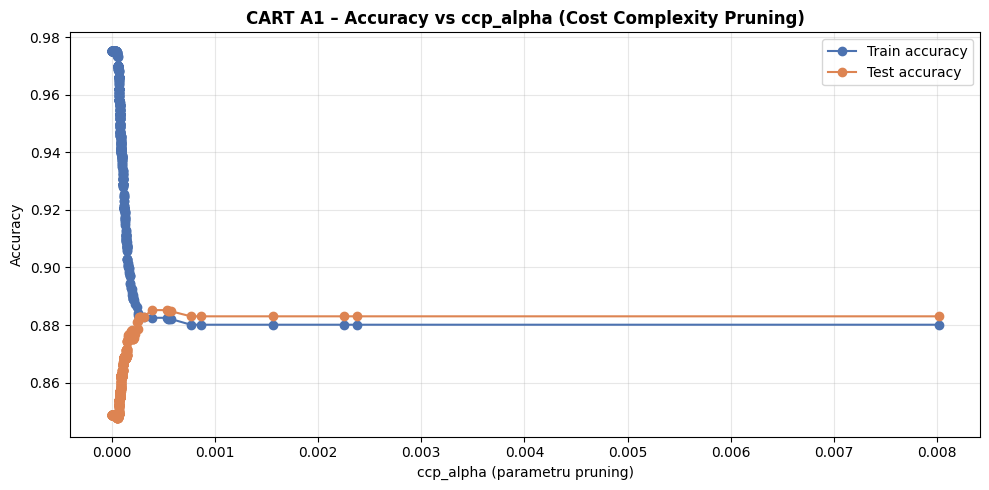

Alpha optim ales : 0.000390


In [4]:
path = cart_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  ## elim ultimul (arborele gol)
 
## Antrenam un arbore pentru fiecare alpha
train_scores, test_scores = [], []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(criterion='gini', ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))
 
## Vizualizare alpha vs accuracy
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas, train_scores, 'o-', label='Train accuracy', color='#4C72B0')
ax.plot(ccp_alphas, test_scores,  'o-', label='Test accuracy',  color='#DD8452')
ax.set_xlabel('ccp_alpha (parametru pruning)')
ax.set_ylabel('Accuracy')
ax.set_title('CART A1 – Accuracy vs ccp_alpha (Cost Complexity Pruning)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
 
## Alegem alpha optim = cel care maxim test accuracy
best_alpha = ccp_alphas[np.argmax(test_scores)]
print(f"Alpha optim ales : {best_alpha:.6f}")

In [6]:
cart_pruned = DecisionTreeClassifier(
    criterion='gini',
    ccp_alpha=best_alpha,
    min_samples_leaf=20,
    min_samples_split=40,
    random_state=7
)
cart_pruned.fit(X_train, y_train)
 
print(f"Adâncime maximă: {cart_pruned.get_depth()}")
print(f"Număr noduri : {cart_pruned.tree_.node_count}")
print(f"Număr frunze : {cart_pruned.get_n_leaves()}")
print(f"Accuracy train: {cart_pruned.score(X_train, y_train):.4f}")
print(f"Accuracy test: {cart_pruned.score(X_test, y_test):.4f}")

Adâncime maximă: 5
Număr noduri : 27
Număr frunze : 14
Accuracy train: 0.8813
Accuracy test: 0.8839


### Vizualizarea arborelui

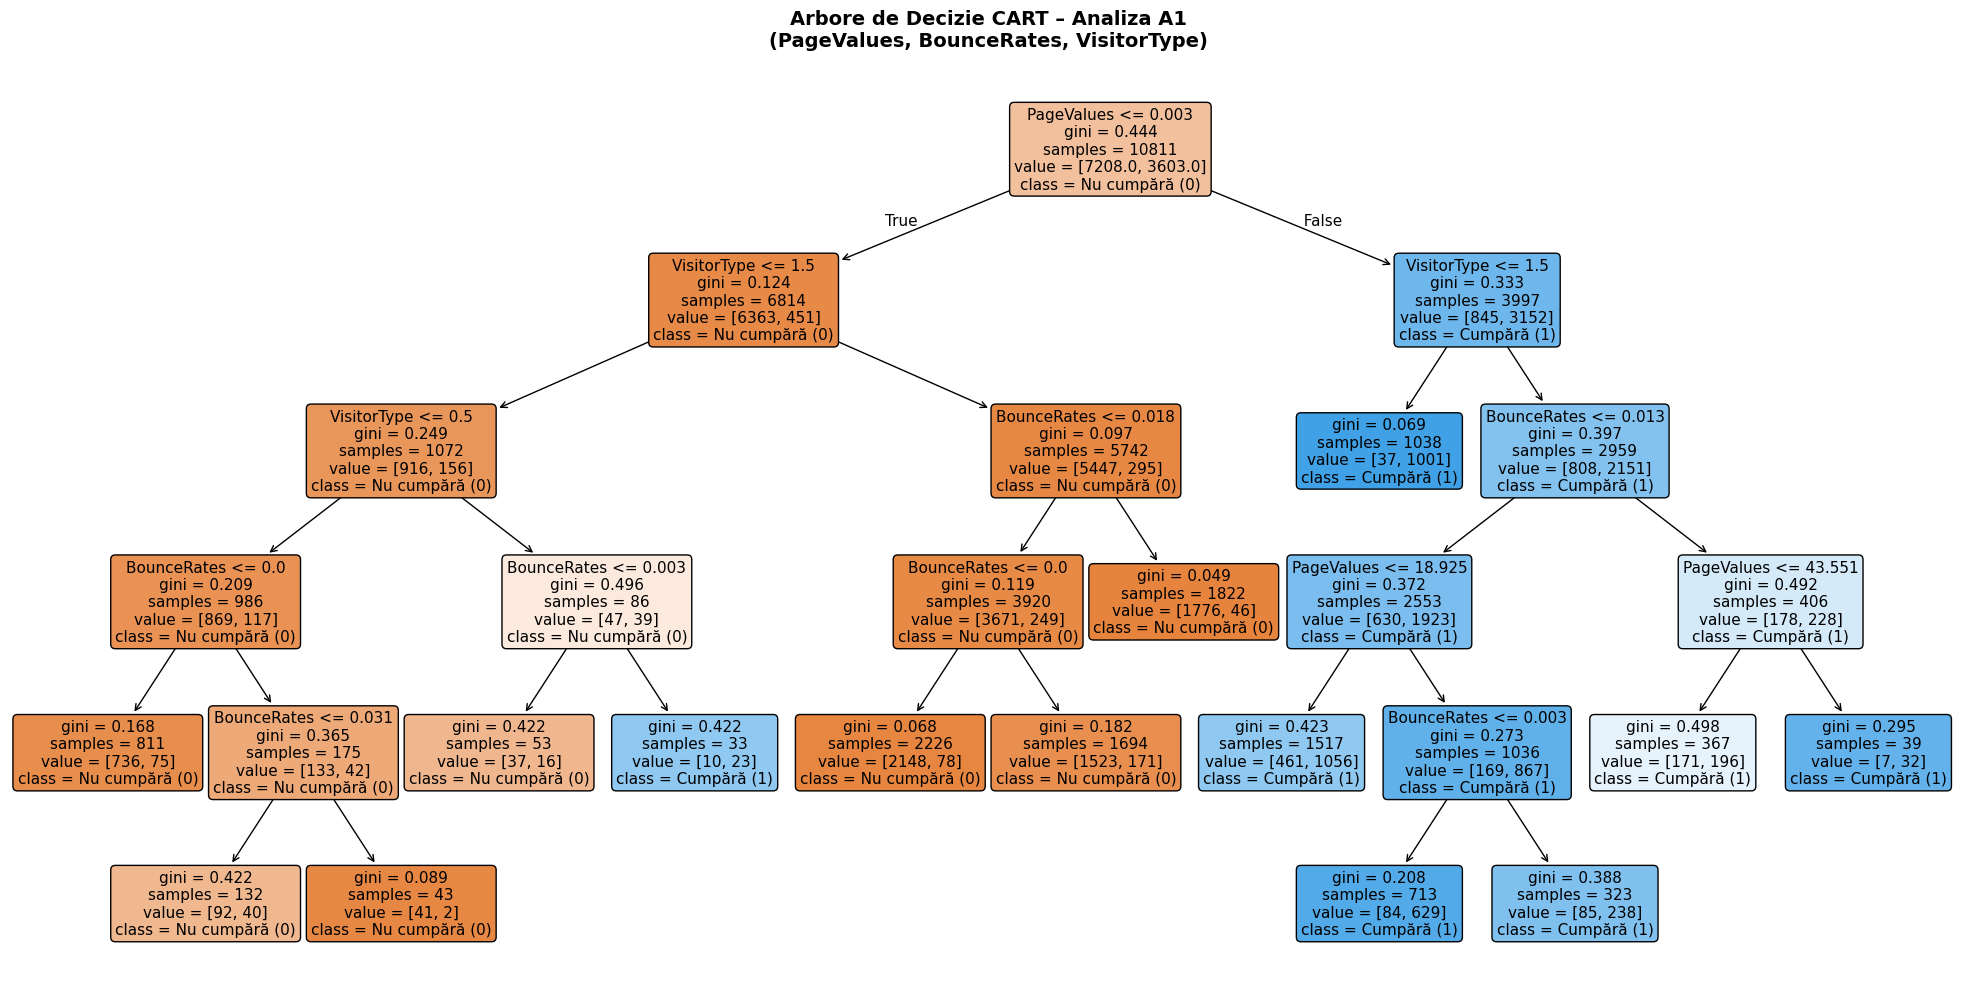

In [7]:
feature_names = X_train.columns.tolist()
class_names   = ['Nu cumpără (0)', 'Cumpără (1)']
 
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(cart_pruned,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=11,
          ax=ax,
          impurity=True,
          proportion=False)
ax.set_title('Arbore de Decizie CART – Analiza A1\n(PageValues, BounceRates, VisitorType)',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Evaluarea modelului

In [10]:
y_pred = cart_pruned.predict(X_test)
y_pred_prob = cart_pruned.predict_proba(X_test)[:, 1]
 
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
auc = roc_auc_score(y_test, y_pred_prob)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
 
print(f"\nMETRICI DE PERFORMANȚĂ:")
print(f"{'Accuracy':<20}: {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"{'Precision':<20}: {precision:.4f}")
print(f"{'Recall (Sensitivity)':<20}: {recall:.4f}")
print(f"{'Specificity':<20}: {specificity:.4f}")
print(f"{'F1-Score':<20}: {f1:.4f}")
print(f"{'AUC-ROC':<20}: {auc:.4f}")
 
# Cross-validation
cv_scores = cross_val_score(cart_pruned, X_train, y_train, cv=10, scoring='f1')
print(f"\nCROSS-VALIDATION (10-fold) F1:")
print(f"Scoruri: {cv_scores.round(4)}")
print(f"Medie  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


METRICI DE PERFORMANȚĂ:
Accuracy            : 0.8839  (88.39%)
Precision           : 0.7946
Recall (Sensitivity): 0.8790
Specificity         : 0.8864
F1-Score            : 0.8347
AUC-ROC             : 0.9226

CROSS-VALIDATION (10-fold) F1:
Scoruri: [0.8529 0.8351 0.8268 0.8373 0.8211 0.8158 0.8349 0.8288 0.8132 0.8292]
Medie  : 0.8295 ± 0.0109


### Vizualizari evaluare

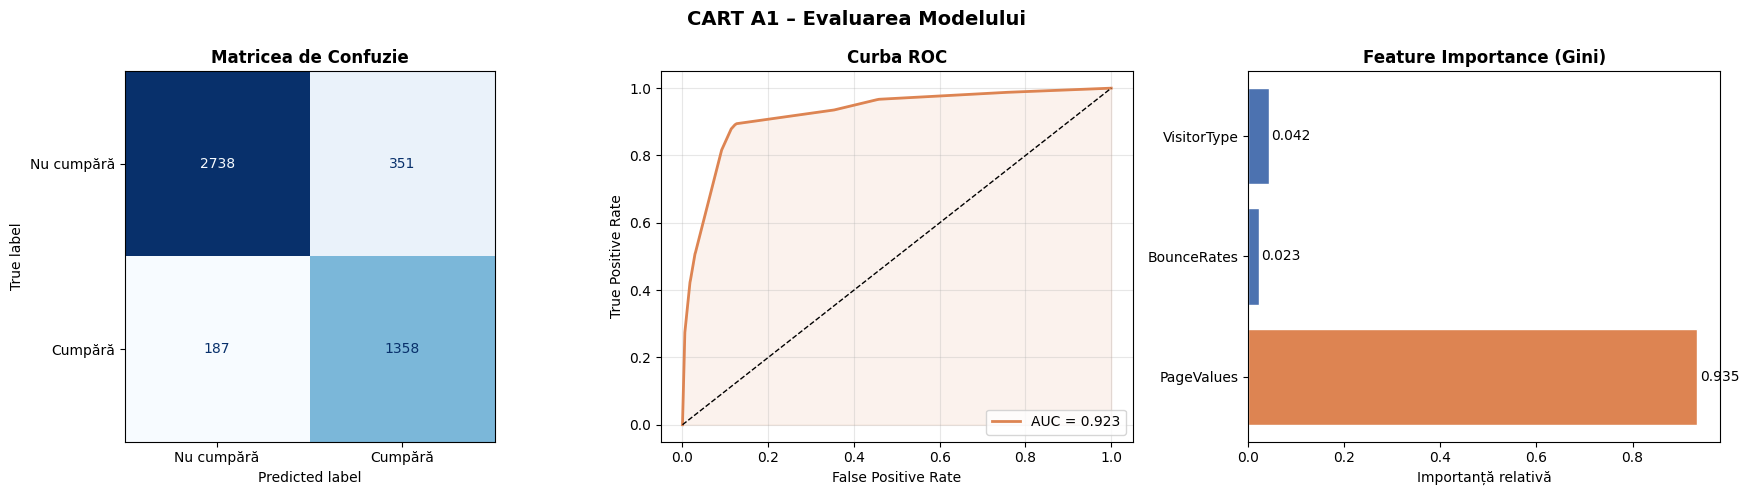

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CART A1 – Evaluarea Modelului', fontsize=14, fontweight='bold')
 
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Nu cumpără', 'Cumpără'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matricea de Confuzie', fontweight='bold')
 
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#DD8452', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#DD8452')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curba ROC', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)
 
importances = cart_pruned.feature_importances_
axes[2].barh(feature_names, importances,
             color=['#DD8452' if i == np.argmax(importances) else '#4C72B0'
                    for i in range(len(importances))],
             edgecolor='white')
axes[2].set_title('Feature Importance (Gini)', fontweight='bold')
axes[2].set_xlabel('Importanță relativă')
for i, v in enumerate(importances):
    axes[2].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
 
plt.tight_layout()
plt.show()

### Extragerea regulilor

In [12]:
rules = export_text(cart_pruned, feature_names=feature_names)
print(rules)

|--- PageValues <= 0.00
|   |--- VisitorType <= 1.50
|   |   |--- VisitorType <= 0.50
|   |   |   |--- BounceRates <= 0.00
|   |   |   |   |--- class: 0
|   |   |   |--- BounceRates >  0.00
|   |   |   |   |--- BounceRates <= 0.03
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- BounceRates >  0.03
|   |   |   |   |   |--- class: 0
|   |   |--- VisitorType >  0.50
|   |   |   |--- BounceRates <= 0.00
|   |   |   |   |--- class: 0
|   |   |   |--- BounceRates >  0.00
|   |   |   |   |--- class: 1
|   |--- VisitorType >  1.50
|   |   |--- BounceRates <= 0.02
|   |   |   |--- BounceRates <= 0.00
|   |   |   |   |--- class: 0
|   |   |   |--- BounceRates >  0.00
|   |   |   |   |--- class: 0
|   |   |--- BounceRates >  0.02
|   |   |   |--- class: 0
|--- PageValues >  0.00
|   |--- VisitorType <= 1.50
|   |   |--- class: 1
|   |--- VisitorType >  1.50
|   |   |--- BounceRates <= 0.01
|   |   |   |--- PageValues <= 18.92
|   |   |   |   |--- class: 1
|   |   |   |--- PageValues >  18.

### Salvare model + rezultate

In [13]:
joblib.dump(cart_pruned, '../../data/processed/cart_a1_model.pkl')

['../../data/processed/cart_a1_model.pkl']

In [14]:
results_a1 = {
    'model': 'CART', 'analiza': 'A1',
    'features': feature_names,
    'depth': cart_pruned.get_depth(),
    'n_leaves': cart_pruned.get_n_leaves(),
    'accuracy': round(accuracy, 4),
    'precision': round(precision, 4),
    'recall': round(recall, 4),
    'f1': round(f1, 4),
    'auc': round(auc, 4),
    'cv_f1_mean': round(cv_scores.mean(), 4),
    'cv_f1_std': round(cv_scores.std(), 4)
}
 
pd.DataFrame([results_a1]).to_csv('../../outputs/cart_a1_results.csv', index=False)
 

### OBS:

-   AUC de 0.92 pe doar 3 variabile -> very nice

-   PageValues e extrem de discriminant
